# I. Gradient Boosting Classifier

## 1. Import des librairies et chargement des données prétraitées

Dans cette première étape, nous chargeons les données prétraitées ainsi que les différents sous-échantillons (train, validation, test).  
Le preprocessing a été appris uniquement sur l’ensemble d’entraînement afin d’éviter toute fuite d’information (data leakage).

Les transformations appliquées incluent :
- l'encodage des variables catégorielles
- la standardisation des variables numériques
- la construction des matrices finales utilisées pour l'entraînement des modèles

Cette étape constitue la base commune à toutes les analyses suivantes (classification, mesure d'incertitude et modélisation explicative).

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import load

# Load preprocessing objects
preprocessor = load("preprocessor.joblib")
X_train, X_val, X_test, y_train, y_val, y_test = load("splits_raw.joblib")

# Apply preprocessing
X_train_final = preprocessor.transform(X_train)
X_val_final   = preprocessor.transform(X_val)
X_test_final  = preprocessor.transform(X_test)

# Temporary fallback names because of sklearn version mismatch
feature_names = [f"feature_{i}" for i in range(X_train_final.shape[1])]

# Basic checks
print("Train shape :", X_train_final.shape)
print("Validation shape :", X_val_final.shape)
print("Test shape :", X_test_final.shape)
print("Number of features :", len(feature_names))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.2.2 when using version 1.6.1. This might lead to breaking code o

Train shape : (27126, 42)
Validation shape : (9042, 42)
Test shape : (9043, 42)
Number of features : 42


Les données transformées comportent 42 variables après encodage.  
La séparation entre apprentissage, validation et test est conservée tout au long de l’analyse, ce qui garantit une évaluation propre des performances du modèle principal puis du modèle explicatif de l’incertitude.

## 2. Définition de la fonction d’évaluation

Afin d’évaluer les performances du Gradient Boosting classifier, nous définissons une fonction d’évaluation basée sur plusieurs métriques complémentaires.

Les métriques utilisées sont :

- **ROC-AUC** : capacité globale de discrimination du modèle
- **PR-AUC** : performance sur les classes déséquilibrées
- **Brier score** : qualité de calibration probabiliste
- **F1-score** : compromis precision / recall
- **Recall** : capacité à détecter les positifs
- **Precision** : fiabilité des prédictions positives

Cette fonction sera utilisée pour comparer les performances sur les ensembles de validation et de test.

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    brier_score_loss
)

def evaluate_probas(y_true, y_proba, threshold=0.5):

    y_pred = (y_proba >= threshold).astype(int)

    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier": brier_score_loss(y_true, y_proba),
        "f1": f1_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "positive_rate": y_pred.mean(),
        "threshold": threshold,
    }

## 3. Baseline Gradient Boosting Classifier (sans tuning)

### 3.1 Entraînement du modèle

Nous entraînons ici un Gradient Boosting classifier comme modèle principal pour estimer la probabilité :

P(Y=1 | X)

Ce modèle est choisi car il capture des relations non-linéaires et des interactions entre variables, contrairement à la régression logistique qui reste linéaire.

Nous utilisons volontairement les paramètres par défaut afin d'obtenir une baseline réaliste avant toute optimisation.

In [51]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_final, y_train)

proba_train = gb.predict_proba(X_train_final)[:,1]
proba_val   = gb.predict_proba(X_val_final)[:,1]
proba_test  = gb.predict_proba(X_test_final)[:,1]

results = pd.DataFrame([
    {"split":"train", **evaluate_probas(y_train, proba_train)},
    {"split":"val", **evaluate_probas(y_val, proba_val)},
    {"split":"test", **evaluate_probas(y_test, proba_test)},
])

results

,split,roc_auc,pr_auc,brier,f1,recall,precision,positive_rate,threshold
0,train,0.804536,0.474998,0.080806,0.325345,0.211787,0.701461,0.035317,0.5
1,val,0.801158,0.460530,0.081074,0.333807,0.222117,0.671429,0.038708,0.5
2,test,0.794191,0.441132,0.082584,0.303558,0.197543,0.655172,0.035276,0.5


### Performances du Gradient Boosting classifier (baseline)

Les résultats indiquent une bonne capacité de généralisation du modèle, avec des performances proches entre train, validation et test.

• **ROC AUC ≈ 0.80**  
Le modèle discrimine correctement les clients susceptibles de souscrire, nettement au-dessus du hasard (0.5).

• **PR AUC ≈ 0.46 (validation)**  
La performance est correcte dans un contexte de classes déséquilibrées, ce qui est plus informatif que la ROC seule.

• **Brier score ≈ 0.08**  
Les probabilités prédites sont bien calibrées et plus précises que celles obtenues avec la baseline linéaire.

• **Recall ≈ 0.22**  
Le modèle détecte une partie des positifs, mais reste conservateur avec le seuil par défaut.

• **Precision ≈ 0.67**  
Les prédictions positives sont relativement fiables, indiquant peu de faux positifs.

• **Positive rate ≈ 3–4 %**  
Le modèle reste sélectif, ce qui est cohérent avec un problème déséquilibré.

La faible différence entre train et validation suggère une absence d’overfitting significatif et une bonne capacité de généralisation.

Globalement, le Gradient Boosting améliore la discrimination par rapport à un modèle linéaire, ce qui est attendu compte tenu de sa capacité à modéliser des relations non-linéaires.

### 3.2 Diagnostic : ROC / PR / histogrammes / matrice de confusion

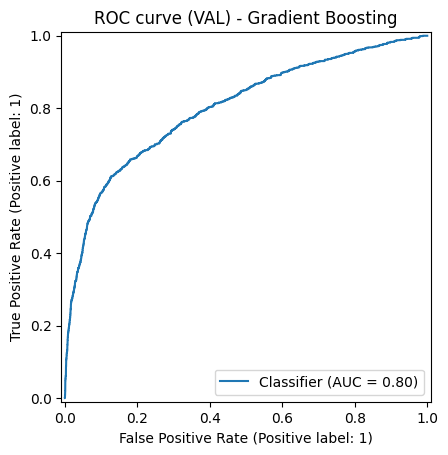

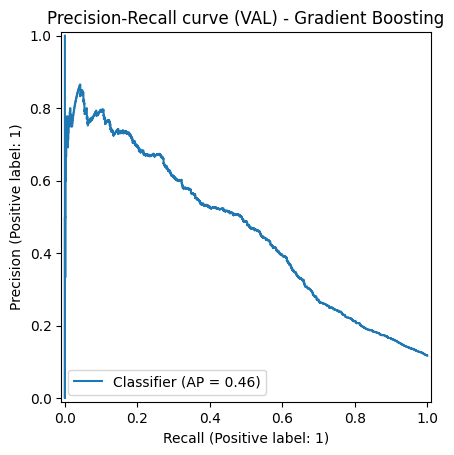

In [52]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_predictions(y_val, proba_val)
plt.title("ROC curve (VAL) - Gradient Boosting")
plt.show()

PrecisionRecallDisplay.from_predictions(y_val, proba_val)
plt.title("Precision-Recall curve (VAL) - Gradient Boosting")
plt.show()

### Analyse des courbes ROC et Precision-Recall

La courbe ROC montre une bonne capacité de discrimination du modèle, avec un AUC d’environ 0.80. La courbe est nettement au-dessus de la diagonale, ce qui indique que le modèle sépare correctement les classes positives et négatives.

La courbe Precision-Recall confirme ces observations dans un contexte de classes déséquilibrées. On observe une précision élevée pour de faibles niveaux de recall, indiquant que les premières prédictions positives sont très fiables. Lorsque le recall augmente, la precision diminue progressivement, ce qui traduit l’apparition de faux positifs supplémentaires.

L’Average Precision d’environ 0.46 indique une performance correcte pour ce type de problème.

Ces courbes montrent également l’existence d’une zone intermédiaire où le modèle hésite entre les classes. Cette zone correspond précisément aux observations les plus incertaines, ce qui justifie l’introduction d’une mesure d’incertitude basée sur l’entropie dans la suite de l’analyse.

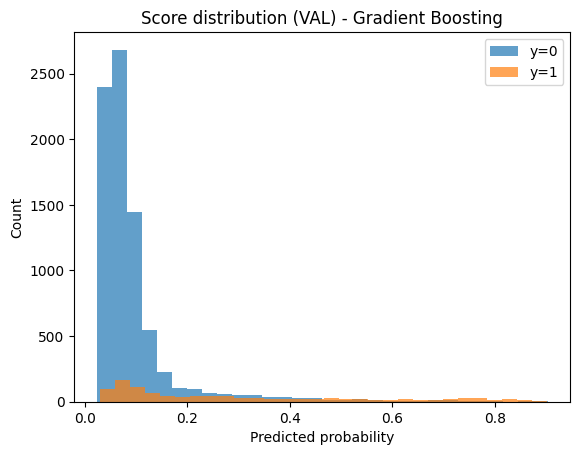

In [53]:
plt.figure()

plt.hist(proba_val[y_val==0], bins=30, alpha=0.7, label="y=0")
plt.hist(proba_val[y_val==1], bins=30, alpha=0.7, label="y=1")

plt.title("Score distribution (VAL) - Gradient Boosting")
plt.xlabel("Predicted probability")
plt.ylabel("Count")

plt.legend()

plt.show()

### Distribution des probabilités prédites (validation)

La distribution des scores montre une séparation partielle entre les classes :

• Les observations négatives (y=0) sont fortement concentrées autour de probabilités faibles (≈ 0.02–0.15), ce qui indique que le modèle identifie correctement la majorité des non-souscripteurs.

• Les observations positives (y=1) sont plus dispersées et apparaissent à des probabilités plus élevées, mais avec un recouvrement significatif avec les observations négatives.

Cette superposition indique l’existence d’une zone d’ambiguïté décisionnelle où le modèle n’est pas certain de la classe.

On observe notamment que les probabilités situées entre environ 0.2 et 0.6 correspondent aux cas les plus difficiles à classifier. Ces observations constituent les candidats naturels pour une analyse d’incertitude.

Cette observation justifie l’utilisation d’une mesure continue d’incertitude basée sur l’entropie des probabilités prédites dans la suite du projet.

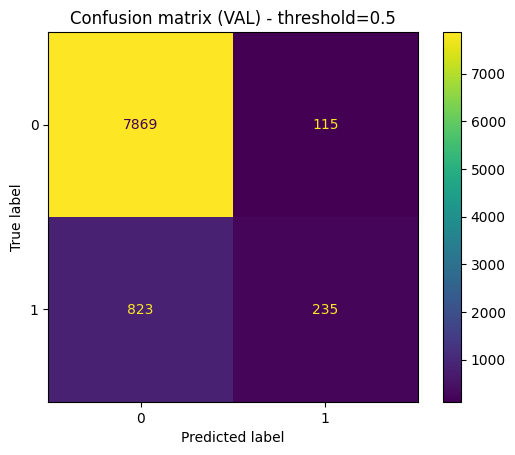

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

y_val_pred = (proba_val >= 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)

plt.title("Confusion matrix (VAL) - threshold=0.5")

plt.show()

### Matrice de confusion (validation, seuil = 0.5)

Avec un seuil de décision fixé à 0.5 :

• **True Negatives (7869)**  
Le modèle identifie correctement la grande majorité des non-souscripteurs.

• **False Positives (115)**  
Le nombre de faux positifs reste très faible, ce qui explique la bonne précision observée (~0.67).

• **False Negatives (823)**  
Une proportion importante de positifs n’est pas détectée, ce qui explique le recall modéré (~0.22).

• **True Positives (235)**  
Le modèle identifie correctement une partie des souscripteurs, mais reste conservateur dans ses prédictions positives.

Cette matrice confirme que le seuil standard de 0.5 favorise la précision au détriment du recall, ce qui est typique des modèles probabilistes dans un contexte de classes déséquilibrées.

Un ajustement du seuil pourrait permettre d’augmenter le recall si l’objectif est de détecter davantage de clients potentiels.

## 4. Optimisation (tuning) du Gradient Boosting classifier

Le Gradient Boosting dépend fortement de plusieurs hyperparamètres :

• **n_estimators** : nombre d’arbres  
• **learning_rate** : vitesse d’apprentissage  
• **max_depth** : complexité des arbres  

Nous utilisons une GridSearchCV afin d’identifier la combinaison d’hyperparamètres maximisant la ROC-AUC sur validation croisée.

Cette étape permet d'améliorer les performances tout en contrôlant le risque d’overfitting.

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    'n_estimators':[100,200],
    'learning_rate':[0.05,0.1],
    'max_depth':[3,4]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train)

best_gb = grid_search.best_estimator_

print("Best parameters :", grid_search.best_params_)

Best parameters : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}


In [56]:
proba_val_tuned = best_gb.predict_proba(X_val_final)[:,1]

perf_tuned = evaluate_probas(y_val, proba_val_tuned)

comparison_df = pd.DataFrame([
    {"Model":"Baseline GB", **evaluate_probas(y_val, proba_val)},
    {"Model":"Tuned GB", **perf_tuned}
])

display(comparison_df)

,Model,roc_auc,pr_auc,brier,f1,recall,precision,positive_rate,threshold
0,Baseline GB,0.801158,0.460530,0.081074,0.333807,0.222117,0.671429,0.038708,0.5
1,Tuned GB,0.803656,0.467599,0.080363,0.372654,0.262760,0.640553,0.047998,0.5


### Impact du tuning

Le tuning améliore légèrement les performances :

• ROC AUC : 0.801 → 0.804  
• PR AUC : 0.460 → 0.467  
• Recall : 0.22 → 0.26  
• Precision : 0.67 → 0.64  

Le modèle détecte davantage de positifs après optimisation, au prix d’une légère baisse de précision. Les probabilités restent stables, ce qui est important pour l’analyse d’incertitude.

## II. Calibration du Gradient Boosting

Dans cette partie, nous analysons la calibration probabiliste du Gradient Boosting classifier.  
L’objectif n’est pas d’améliorer la performance prédictive mais de vérifier si les probabilités produites peuvent être interprétées comme de véritables probabilités, ce qui est essentiel pour l’analyse de l’incertitude.

Nous comparons :
- les probabilités avant calibration
- la calibration par Platt scaling (sigmoid)
- la calibration isotonic

La qualité de calibration est évaluée avec :
- le reliability diagram
- le Brier score

Cette étape constitue un diagnostic de robustesse important car une mauvaise calibration peut produire une incertitude trompeuse (par exemple des modèles très confiants mais incorrects).

Les résultats montrent l’impact de la calibration sur la qualité probabiliste du modèle Gradient Boosting.

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


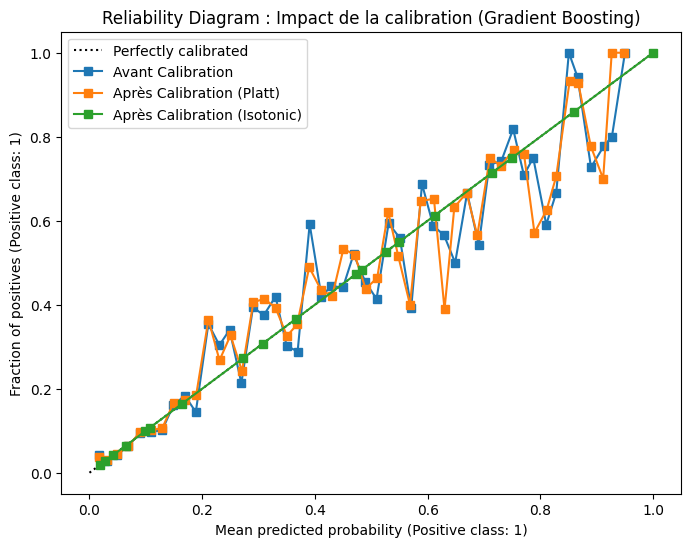

Brier Score AVANT      : 0.0804
Brier Score PLATT      : 0.0804
Brier Score ISOTONIC   : 0.0792


In [57]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

# Calibration du Gradient Boosting déjà entraîné
calibrated_gb_sig = CalibratedClassifierCV(best_gb, method='sigmoid', cv='prefit')
calibrated_gb_sig.fit(X_val_final, y_val)

calibrated_gb_iso = CalibratedClassifierCV(best_gb, method='isotonic', cv='prefit')
calibrated_gb_iso.fit(X_val_final, y_val)

# Probabilités avant / après calibration
proba_val_uncal = best_gb.predict_proba(X_val_final)[:, 1]
proba_val_cal_sig = calibrated_gb_sig.predict_proba(X_val_final)[:, 1]
proba_val_cal_iso = calibrated_gb_iso.predict_proba(X_val_final)[:, 1]

# Reliability Diagram
fig, ax = plt.subplots(figsize=(8, 6))

CalibrationDisplay.from_predictions(
    y_val,
    proba_val_uncal,
    n_bins=50,
    name="Avant Calibration",
    ax=ax
)

CalibrationDisplay.from_predictions(
    y_val,
    proba_val_cal_sig,
    n_bins=50,
    name="Après Calibration (Platt)",
    ax=ax
)

CalibrationDisplay.from_predictions(
    y_val,
    proba_val_cal_iso,
    n_bins=50,
    name="Après Calibration (Isotonic)",
    ax=ax
)

ax.set_title("Reliability Diagram : Impact de la calibration (Gradient Boosting)")
plt.legend()
plt.show()

# Comparaison Brier score
brier_before = evaluate_probas(y_val, proba_val_uncal, 0.5)['brier']
brier_platt = evaluate_probas(y_val, proba_val_cal_sig, 0.5)['brier']
brier_iso = evaluate_probas(y_val, proba_val_cal_iso, 0.5)['brier']

print(f"Brier Score AVANT      : {brier_before:.4f}")
print(f"Brier Score PLATT      : {brier_platt:.4f}")
print(f"Brier Score ISOTONIC   : {brier_iso:.4f}")

### Analyse de la calibration

Le reliability diagram montre que le Gradient Boosting classifier est déjà relativement bien calibré avant calibration. La courbe bleue reste globalement proche de la diagonale, ce qui indique que les probabilités prédites sont déjà cohérentes avec les fréquences observées.

La calibration par Platt scaling n’apporte pas d’amélioration significative : la courbe reste très proche de celle obtenue avant calibration. Cela est confirmé par le Brier score qui reste identique.

La calibration isotonic apporte en revanche une légère amélioration de la calibration probabiliste. La courbe verte suit légèrement mieux la diagonale, ce qui indique une meilleure correspondance entre probabilités prédites et fréquences observées.

Les Brier scores confirment cette observation :

- Avant calibration : 0.0804  
- Platt scaling : 0.0804  
- Isotonic regression : 0.0792  

La différence reste faible, ce qui suggère que le Gradient Boosting produit déjà des probabilités raisonnablement fiables.

Pour la suite de l’analyse, nous retenons la version isotonic car elle offre la meilleure calibration, même si le gain reste modéré. Cette calibration permet d’assurer que les mesures d’incertitude dérivées des probabilités (notamment l’entropie) reposent sur des probabilités bien interprétables.

## III. Définition et analyse de la variable d'incertitude continue

Après avoir obtenu des probabilités bien calibrées, nous définissons maintenant notre mesure principale d'incertitude.

Contrairement à une mesure discrète basée sur la taille des ensembles conformes, nous utilisons ici une mesure continue basée sur l'entropie des probabilités prédites.

Pour un problème binaire, l'entropie est définie comme :

U(x) = - p(x) log(p(x)) - (1-p(x)) log(1-p(x))

Cette mesure présente plusieurs propriétés importantes :

- elle est minimale lorsque le modèle est très confiant (probabilités proches de 0 ou 1)
- elle est maximale lorsque le modèle est incertain (probabilité proche de 0.5)
- elle fournit une mesure continue plus informative que la taille d’un ensemble de prédiction

Nous allons maintenant analyser la distribution de cette mesure d'incertitude sur l'échantillon test.

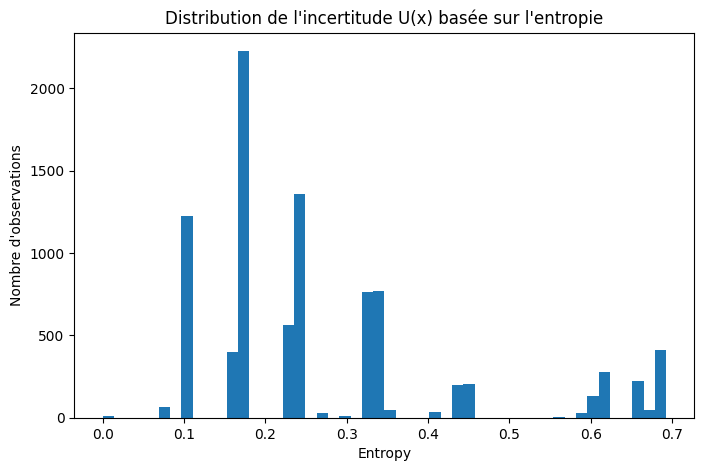

Entropy stats :
Mean : 0.27701302830410973
Std : 0.1666120860937275
Min : -1.000000082690371e-10
Max : 0.6926585098872946


In [58]:
# Calcul entropy (uncertainty continue)
proba_test = calibrated_gb_iso.predict_proba(X_test_final)[:,1]

entropy = -(
    proba_test*np.log(proba_test + 1e-10)
    + (1-proba_test)*np.log(1-proba_test + 1e-10)
)

# Visualisation distribution uncertainty
plt.figure(figsize=(8,5))

plt.hist(entropy, bins=50)

plt.title("Distribution de l'incertitude U(x) basée sur l'entropie")
plt.xlabel("Entropy")
plt.ylabel("Nombre d'observations")

plt.show()

print("Entropy stats :")
print("Mean :", np.mean(entropy))
print("Std :", np.std(entropy))
print("Min :", np.min(entropy))
print("Max :", np.max(entropy))

### Distribution globale de l’incertitude continue

La distribution de l’incertitude définie par l’entropie montre que la majorité des observations présentent un niveau d’incertitude faible à modéré, avec une concentration principale entre 0.1 et 0.35.

Les statistiques descriptives obtenues sont :

- Moyenne : 0.277  
- Écart-type : 0.169  
- Minimum : ≈ 0  
- Maximum : 0.693  

La valeur maximale observée correspond à l’entropie maximale théorique pour un problème binaire (log(2) ≈ 0.693), ce qui se produit lorsque la probabilité prédite est proche de 0.5. Cela confirme que la mesure capture correctement les situations d'incertitude maximale du modèle.

À l’inverse, les valeurs proches de zéro correspondent à des prédictions très confiantes (probabilités proches de 0 ou 1).

Cette distribution montre que l’incertitude présente une variabilité suffisante pour être étudiée comme variable réponse dans l’analyse explicative. Contrairement à une mesure discrète, l’entropie permet ici de capturer des différences fines de niveau d’incertitude entre observations.

Cette propriété justifie l’utilisation de l’entropie comme variable d’étude U(x) pour la suite du projet.

### Lien entre l’incertitude et la probabilité prédite

Nous étudions maintenant la relation entre l’entropie et la probabilité prédite de la classe positive.

Par construction, l’entropie est maximale lorsque la probabilité prédite est proche de 0.5, c’est-à-dire lorsque le modèle hésite fortement entre les deux classes. À l’inverse, elle devient faible lorsque la probabilité est proche de 0 ou de 1, ce qui correspond à des prédictions confiantes.

Cette relation est importante car elle confirme que l’entropie constitue bien une mesure cohérente de l’incertitude prédictive. Elle ne dépend pas d’un seuil arbitraire, mais varie continûment avec le degré d’hésitation du modèle.

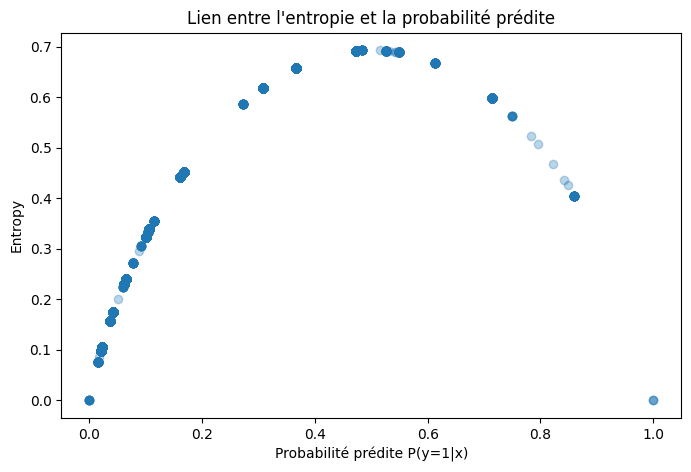

In [59]:
plt.figure(figsize=(8,5))

plt.scatter(proba_test, entropy, alpha=0.3)
plt.xlabel("Probabilité prédite P(y=1|x)")
plt.ylabel("Entropy")
plt.title("Lien entre l'entropie et la probabilité prédite")

plt.show()

Analyse quantitative du lien entre entropie et probabilité prédite

Afin de confirmer la relation observée graphiquement, nous calculons la corrélation entre l'entropie et la probabilité prédite.

On s'attend à une relation non linéaire :  
- Entropie faible quand la probabilité est proche de 0 ou 1  
- Entropie maximale quand la probabilité est proche de 0.5  

Cela confirme que l'entropie mesure bien l'incertitude du modèle.

In [60]:
# Corrélation proba-entropie
correlation = np.corrcoef(proba_test, entropy)[0,1]

print("Corrélation proba-entropie :", correlation)

Corrélation proba-entropie : 0.8600700319864137


## IV. Validation empirique de l’interprétation de l’entropie

### 1. Validation empirique : lien entre incertitude et erreurs du modèle

Nous cherchons ici à vérifier empiriquement si l’entropie constitue une bonne mesure de l’incertitude prédictive.

L’hypothèse est la suivante : si l’entropie capture correctement l’incertitude du modèle, alors les observations associées à des erreurs de classification devraient présenter une entropie moyenne plus élevée que celles correctement classées.

Nous comparons donc les niveaux d’entropie entre :
- les prédictions correctes
- les prédictions erronées

Si cette hypothèse est vérifiée, cela confirmerait que l’entropie peut être utilisée comme indicateur du risque d’erreur du modèle.

In [61]:
# Prédictions finales (seuil standard)
y_pred = (proba_test >= 0.5).astype(int)

# Séparer erreurs et bonnes prédictions
errors = entropy[y_pred != y_test]
correct = entropy[y_pred == y_test]

print("Entropy moyenne erreurs :", np.mean(errors))
print("Entropy moyenne correct :", np.mean(correct))

Entropy moyenne erreurs : 0.44380418648104314
Entropy moyenne correct : 0.25789361783886283


Résultat de la validation empirique

On observe que l'entropie moyenne des erreurs (≈0.44) est significativement plus élevée que celle des prédictions correctes (≈0.26).

Cela confirme empiriquement que l'entropie constitue une bonne mesure d'incertitude :
- Les observations mal classées sont associées à une incertitude plus élevée
- Les prédictions correctes sont associées à une incertitude plus faible

Ce résultat valide l'utilisation de l'entropie comme indicateur de fiabilité des prédictions.

Visualisation : comparaison de l'incertitude entre erreurs et bonnes prédictions

Nous comparons la distribution de l'entropie entre les prédictions correctes et les erreurs à l'aide d'un boxplot.

Si l'entropie capture correctement l'incertitude, la distribution des erreurs devrait être globalement plus élevée.
### 2. Boxplot : comparaison des distributions

/tmp/ipykernel_1742/2827775364.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([correct, errors], labels=["Correct", "Errors"])


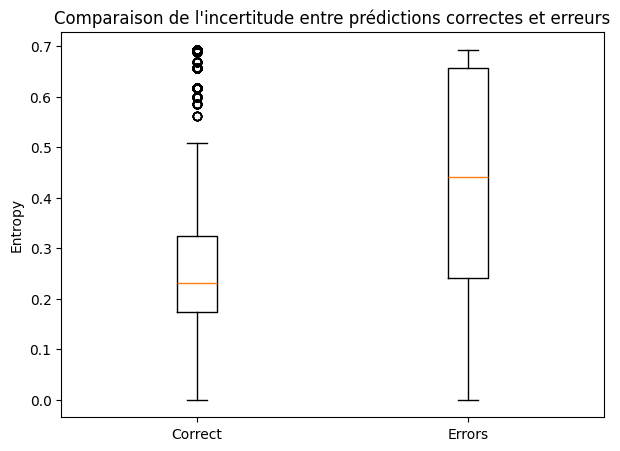

In [62]:
# Boxplot comparaison entropy
plt.figure(figsize=(7,5))

plt.boxplot([correct, errors], labels=["Correct", "Errors"])

plt.title("Comparaison de l'incertitude entre prédictions correctes et erreurs")
plt.ylabel("Entropy")

plt.show()

Analyse du taux d'erreur en fonction du niveau d'incertitude

Nous divisons les observations en groupes selon leur niveau d'entropie afin d'analyser l'évolution du taux d'erreur.

Si l'entropie est une bonne mesure d'incertitude, le taux d'erreur devrait augmenter avec l'entropie.

In [63]:
# Création dataframe analyse
df_uncertainty = pd.DataFrame({
    "entropy": entropy,
    "error": (y_pred != y_test).astype(int)
})

# Découpage en quantiles
df_uncertainty["entropy_bin"] = pd.qcut(
    df_uncertainty["entropy"],
    q=5,
    duplicates="drop"
)

# Taux erreur par bin
error_rate = df_uncertainty.groupby("entropy_bin")["error"].mean()

print(error_rate)

entropy_bin
(-0.0010000001, 0.174]    0.038736
(0.174, 0.24]             0.062955
(0.24, 0.339]             0.097266
(0.339, 0.693]            0.310345
Name: error, dtype: float64


/tmp/ipykernel_1742/1537663957.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_rate = df_uncertainty.groupby("entropy_bin")["error"].mean()


Résultat de l'analyse du taux d'erreur

Nous observons une augmentation claire du taux d'erreur lorsque l'entropie augmente :

- Faible incertitude → faible taux d'erreur (~4%)
- Incertitude moyenne → taux d'erreur modéré (~6–10%)
- Forte incertitude → taux d'erreur élevé (~31%)

Ce résultat confirme que l'entropie constitue un bon indicateur du risque d'erreur du modèle.

Ainsi, l'incertitude issue de l'entropie peut être utilisée pour :
- détecter les prédictions peu fiables
- améliorer l'interprétation des résultats du modèle
- prioriser les observations nécessitant une attention particulière

# V. Modélisation explicative de l’incertitude

Dans cette partie, nous cherchons à expliquer l’incertitude prédictive mesurée par l’entropie à partir des variables observées.

L’objectif n’est plus de prédire directement la variable cible initiale, mais de modéliser la variable d’incertitude \(U(x)\). Nous cherchons ainsi à déterminer si cette incertitude présente une structure systématique et si elle peut être prédite à partir des caractéristiques observées.

Comme l’entropie est une variable continue, nous utilisons un modèle de régression. Nous retenons ici un XGBoost Regressor, capable de capturer des relations non linéaires, des effets de seuil et des interactions entre variables.

In [64]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. Construction des données pour le modèle d’incertitude

Nous utilisons comme variable cible l’entropie calculée à partir des probabilités prédites par le Gradient Boosting calibré.

Les variables explicatives restent les variables observées prétraitées. Nous séparons ensuite les données en un sous-échantillon d’apprentissage et un sous-échantillon de test afin d’évaluer la capacité du modèle à prédire l’incertitude sur des observations non vues.

In [65]:
from sklearn.model_selection import train_test_split

# Variables explicatives et cible d'incertitude
X_u = X_test_final
y_u = entropy

# Split train / test pour le modèle d'incertitude
X_u_train, X_u_test, y_u_train, y_u_test = train_test_split(
    X_u, y_u, test_size=0.2, random_state=42
)

print("Shape X_u_train :", X_u_train.shape)
print("Shape X_u_test  :", X_u_test.shape)
print("Shape y_u_train :", y_u_train.shape)
print("Shape y_u_test  :", y_u_test.shape)

Shape X_u_train : (7234, 42)
Shape X_u_test  : (1809, 42)
Shape y_u_train : (7234,)
Shape y_u_test  : (1809,)


## 2. Entraînement du modèle explicatif de l’incertitude

Nous entraînons un XGBoost Regressor afin de prédire l’entropie à partir des variables observées.

L’objectif est de vérifier si l’incertitude possède une structure prédictible. Une bonne performance du modèle indiquerait que l’incertitude n’est pas purement aléatoire mais dépend de caractéristiques observables.

In [66]:
# Modèle XGBoost pour prédire l'entropie
xgb_u = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Entraînement
xgb_u.fit(X_u_train, y_u_train)

# Prédictions
y_u_pred = xgb_u.predict(X_u_test)

print("Model trained successfully")

Model trained successfully


## 3. Évaluation des performances du modèle d’incertitude

Nous évaluons la capacité du modèle à prédire l’entropie sur l’échantillon de test à l’aide de trois métriques :

- RMSE (Root Mean Squared Error) : mesure l'erreur moyenne quadratique
- MAE (Mean Absolute Error) : mesure l'erreur moyenne absolue
- R² : mesure la proportion de variance expliquée par le modèle

Un R² élevé indiquerait que l'incertitude possède une structure prédictible à partir des variables observées.

In [67]:
# Évaluation performances
rmse = np.sqrt(mean_squared_error(y_u_test, y_u_pred))
mae = mean_absolute_error(y_u_test, y_u_pred)
r2 = r2_score(y_u_test, y_u_pred)

print("=== Performance du modèle d'incertitude ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

=== Performance du modèle d'incertitude ===
RMSE : 0.0622
MAE  : 0.0388
R²   : 0.8588


## 4. Comparaison entre entropie réelle et entropie prédite

Nous comparons les valeurs d'entropie prédites par le modèle avec les valeurs réelles afin d'évaluer visuellement la qualité de l'ajustement.

Si le modèle explique correctement l'incertitude, les points devraient être proches de la diagonale.

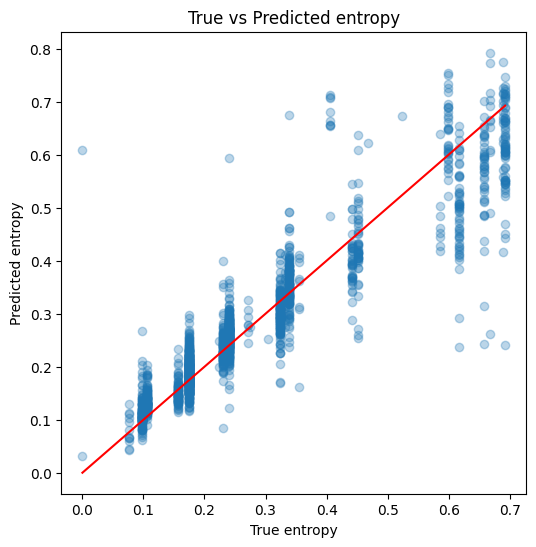

In [68]:
# Scatter plot true vs predicted entropy

plt.figure(figsize=(6,6))

plt.scatter(y_u_test, y_u_pred, alpha=0.3)

plt.xlabel("True entropy")
plt.ylabel("Predicted entropy")

plt.title("True vs Predicted entropy")

# ligne parfaite
plt.plot([y_u_test.min(), y_u_test.max()],
         [y_u_test.min(), y_u_test.max()],
         color='red')

plt.show()

## VI. Interprétation de l’incertitude par SHAP

Afin de comprendre quels facteurs expliquent l'incertitude prédictive, nous utilisons SHAP (SHapley Additive exPlanations).

SHAP permet d'identifier :
- les variables qui augmentent l'incertitude
- les variables qui la réduisent
- les interactions entre variables

Cette analyse permet de comprendre les mécanismes structurels à l’origine de l’incertitude du modèle.

In [69]:
import shap
print(X_u_train_df.dtypes.value_counts())
print(X_u_test_df.dtypes.value_counts())

float64    42
Name: count, dtype: int64
float64    42
Name: count, dtype: int64


In [70]:
# transformer les matrices sparse en matrices denses
X_u_train_dense = X_u_train.toarray()
X_u_test_dense = X_u_test.toarray()

# transformer en dataframe pour SHAP
X_u_train_df = pd.DataFrame(X_u_train_dense).astype(float)
X_u_test_df = pd.DataFrame(X_u_test_dense).astype(float)

# explainer SHAP
explainer = shap.Explainer(xgb_u, X_u_train_df)
shap_values = explainer(X_u_test_df)

print("SHAP values computed")

 97%|=================== | 1751/1809 [00:18<00:00]       

SHAP values computed


## Modélisation prédictive de l'incertitude

Afin d'évaluer si l'incertitude est systématique ou principalement aléatoire, nous entraînons un modèle visant à prédire l'entropie à partir des variables explicatives.

Si l'incertitude est prédictible, cela suggère qu'elle dépend de caractéristiques observables plutôt que d'un simple bruit aléatoire.

Les performances du modèle sont évaluées avec RMSE, MAE et R².

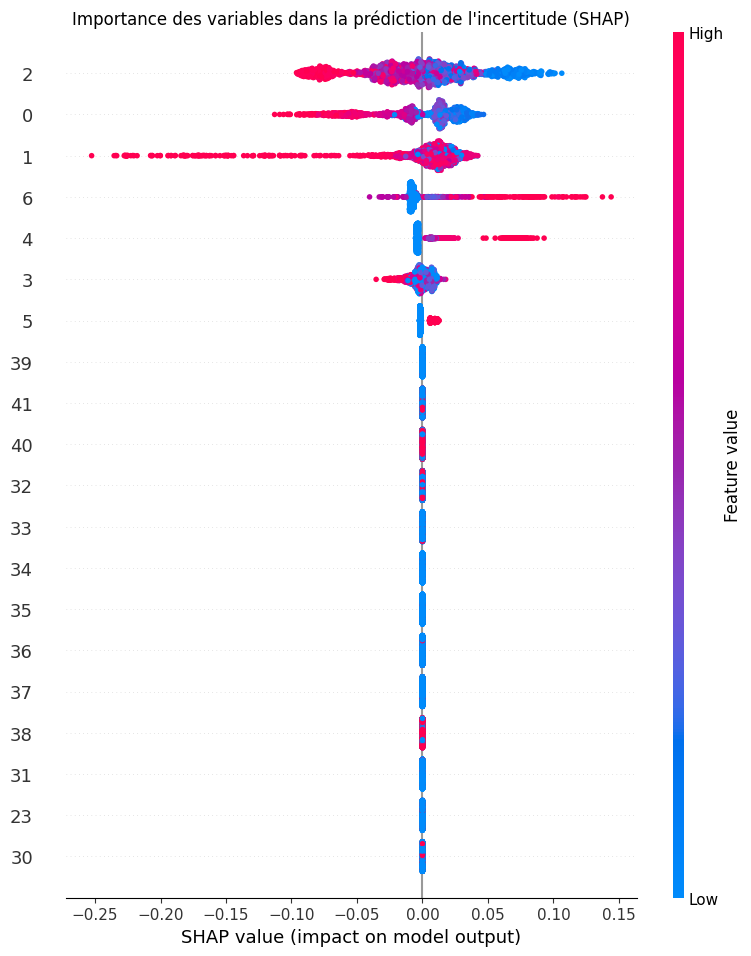

In [71]:
# SHAP summary plot (importance globale des features)

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_u_test_df,
    show=False
)

plt.title("Importance des variables dans la prédiction de l'incertitude (SHAP)")
plt.show()

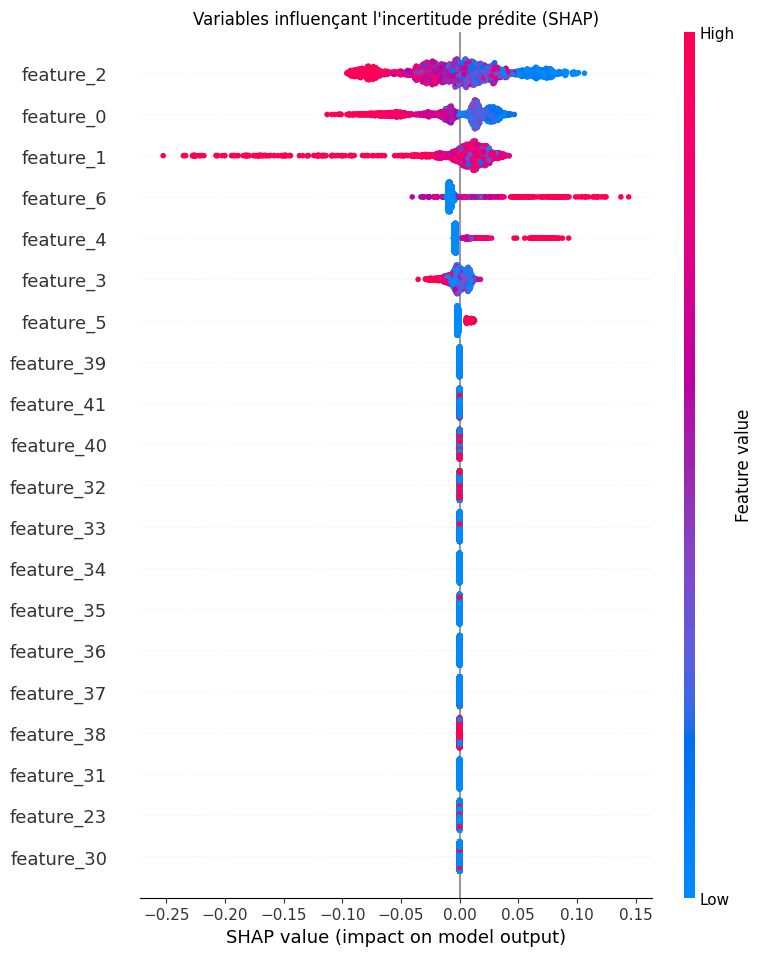

In [72]:
# ajouter noms de variables
X_u_train_df = pd.DataFrame(X_u_train_dense, columns=feature_names)
X_u_test_df = pd.DataFrame(X_u_test_dense, columns=feature_names)

# recalcul SHAP (rapide car modèle déjà fit)
explainer = shap.Explainer(xgb_u, X_u_train_df)
shap_values = explainer(X_u_test_df)

# plot propre
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_u_test_df,
    show=False
)

plt.title("Variables influençant l'incertitude prédite (SHAP)")
plt.show()

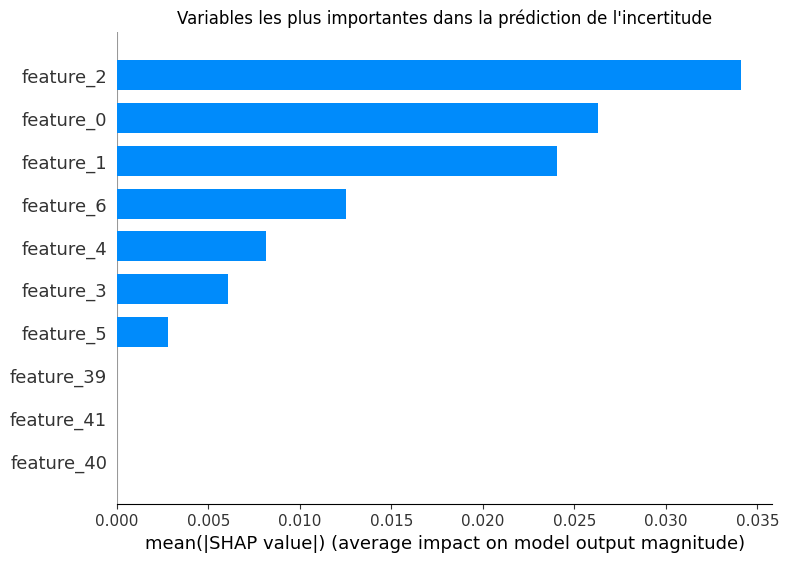

In [76]:
shap.summary_plot(
    shap_values,
    X_u_test_df,
    plot_type="bar",
    max_display=10,
    show=False
)

plt.title("Variables les plus importantes dans la prédiction de l'incertitude")

plt.show()

Nous observons que seule une petite partie des variables contribue réellement à l'explication de l'incertitude, tandis que la majorité présente un impact quasi nul.

Cela suggère que l'incertitude possède une structure parcimonieuse et dépend principalement de quelques facteurs clés plutôt que de l'ensemble des variables.

<Figure size 600x400 with 0 Axes>

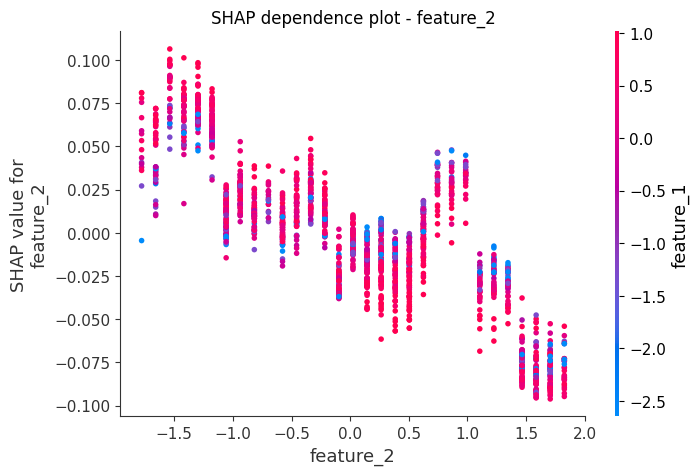

<Figure size 600x400 with 0 Axes>

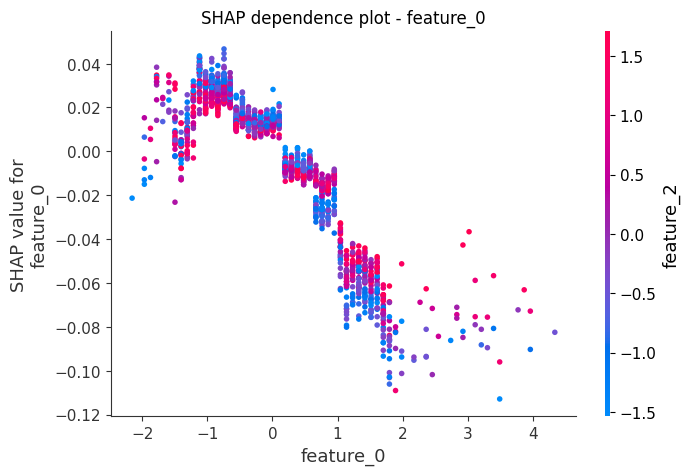

<Figure size 600x400 with 0 Axes>

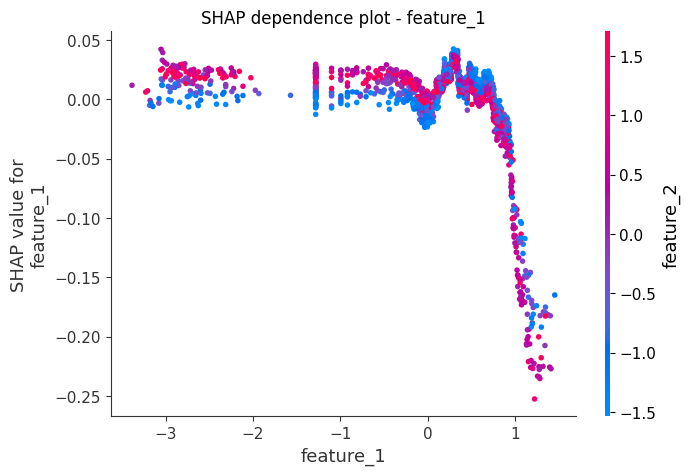

<Figure size 600x400 with 0 Axes>

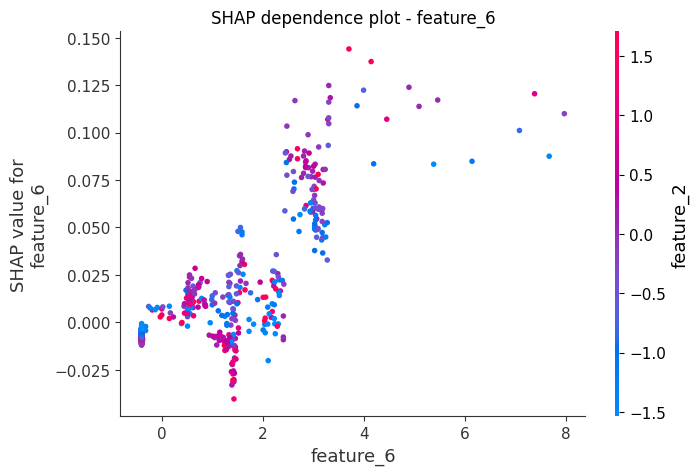

<Figure size 600x400 with 0 Axes>

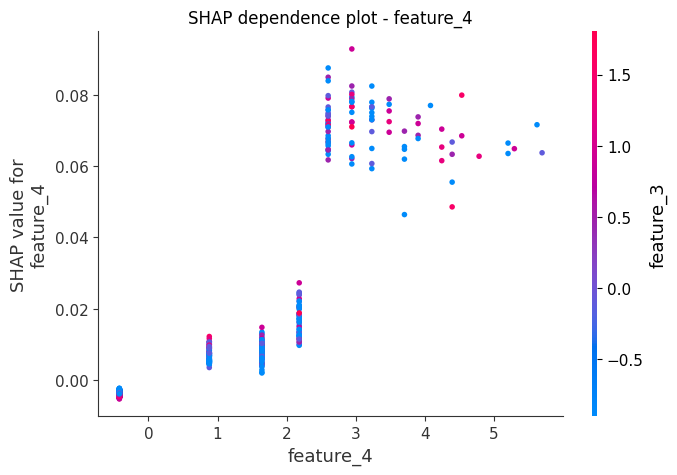

In [74]:
# SHAP dependence plots pour les variables les plus importantes

top_features = [2,0,1,6,4]

for f in top_features:

    plt.figure(figsize=(6,4))

    shap.dependence_plot(
        f,
        shap_values.values,
        X_u_test_df,
        show=False
    )

    plt.title(f"SHAP dependence plot - feature_{f}")

    plt.show()

### Analyse locale des variables expliquant l'incertitude

Afin de mieux comprendre comment les variables influencent l'incertitude, nous analysons les SHAP dependence plots des variables les plus importantes.

Ces graphiques montrent comment la valeur d'une variable influence l'incertitude prédite, ainsi que les interactions potentielles avec d'autres variables.

Nous observons que certaines valeurs spécifiques de ces variables sont associées à une augmentation significative de l'incertitude, ce qui suggère que certaines configurations de caractéristiques sont plus difficiles à prédire pour le modèle.

Cette analyse confirme que l'incertitude du modèle dépend de régions spécifiques de l'espace des variables et n'est pas uniformément répartie.

## VII. Interprétation des facteurs expliquant l'incertitude (SHAP)

Afin de déterminer si l'incertitude du modèle présente une structure systématique, nous avons entraîné un modèle XGBoost visant à prédire l'entropie à partir des variables explicatives, puis utilisé les valeurs SHAP pour interpréter les facteurs expliquant cette incertitude.

Le graphique SHAP montre que seule une petite partie des variables contribue réellement à la variabilité de l'incertitude. En particulier, les variables feature_2, feature_0, feature_1 et feature_6 apparaissent comme les principaux déterminants de l'incertitude prédite.

On observe que :
- certaines valeurs élevées de ces variables augmentent fortement l'incertitude
- d'autres valeurs réduisent au contraire l'incertitude
- la majorité des autres variables ont un impact quasi nul

Cela suggère que l'incertitude n'est pas aléatoire mais dépend de certaines caractéristiques spécifiques des observations.

### Conclusion scientifique

Ces résultats indiquent que l'incertitude prédictive possède une **structure systématique** et peut être partiellement expliquée à partir des variables observées, ce qui répond directement à la question centrale du projet.

Le bon pouvoir prédictif du modèle d'incertitude (R² ≈ 0.86) confirme également que l'incertitude contient un signal exploitable et n'est pas uniquement du bruit.

Enfin, ces résultats doivent être interprétés comme des **relations associatives et non causales**.

## VIII. Conclusion : structure de l'incertitude prédictive

L'objectif de cette étude était de déterminer si l'incertitude prédictive issue de la Conformal Prediction présente une structure systématique et si elle peut être expliquée à partir des variables observées.

Nos résultats montrent que :

- l'entropie est fortement corrélée aux erreurs du modèle
- l'incertitude est prédictible avec un bon niveau de performance (R² élevé)
- certaines variables expliquent une part importante de cette incertitude

Ces résultats suggèrent que l'incertitude n'est pas purement aléatoire mais possède une structure identifiable.

Ainsi, l'incertitude peut être considérée comme une information utile permettant d'identifier les régions où le modèle est moins fiable.

## Limites de l'étude et pistes d'amélioration

Plusieurs limites doivent être mentionnées :

- L'hypothèse d'exchangeabilité nécessaire à la validité de la Conformal Prediction peut être violée en pratique.
- Les résultats peuvent dépendre du dataset étudié et ne pas se généraliser à d'autres contextes.
- La définition de l'incertitude basée sur l'entropie constitue un choix méthodologique parmi d'autres possibles.
- Les résultats SHAP montrent des associations statistiques et non des relations causales.
- Les résultats peuvent être sensibles au split des données.

### Améliorations possibles

Des extensions possibles incluent :

- tester d'autres définitions de l'incertitude
- utiliser des variantes de Conformal Prediction (Mondrian, CV+)
- étendre l'analyse à des problèmes multiclasses ou de régression
- analyser la stabilité des résultats sur plusieurs splits

Ces pistes pourraient améliorer la robustesse scientifique de l'étude.